# Library Import

In [35]:
import cv2
import matplotlib.pyplot as plt
import warnings
from keras import Sequential
from keras.src.callbacks import CSVLogger, TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.src.layers import BatchNormalization, Dense, MaxPooling2D, Dropout, Conv2D, Activation, Flatten
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.optimizers import AdamW
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tqdm import tqdm
from sklearn.utils import shuffle
import plotly.express as px
import plotly.graph_objects as go
import itertools
from keras.src.regularizers import L2
import mlflow

warnings.filterwarnings('ignore')

# PATH

In [36]:
TRAIN_PATH = 'dataset/training/'
PLOT_SAVE_DIR = 'output/plot/v16/'
LOG_DIR = 'output/log/v16/'
MODEL_SAVE_PATH = 'output/model/v16/cnn_model_v16.keras'
HISTORY_PATH = 'output/model/v16/train_history_v16.npy'

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 1)
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 0.0005

LABEL_MAPPING = {
    'alcohol': 0,
    'blood': 1,
    'sexual': 2,
    'traffic_accident': 3
}

CLASS_NAMES = ['alcohol', 'blood', 'sexual', 'traffic_accident']
NB_CLASSES = len(CLASS_NAMES)

# Function to load data

In [37]:
def load_data(dataset, label_mapping, image_size=IMAGE_SIZE):
    """
    Load and preprocess images from the dataset directory.

    Args:
        dataset (str or list): Path(s) to the dataset directory.
        label_mapping (dict): Mapping of folder names to class labels.
        image_size (tuple): Target size for resizing images.

    Returns:
        images (np.ndarray): Array of preprocessed images.
        labels (np.ndarray): Array of corresponding labels.
    """
    images = []
    labels = []

    if isinstance(dataset, str):
        dataset = [dataset]

    for dataset_path in dataset:
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset directory {dataset_path} not found.")

        print(f"Loading data from: {dataset_path}")
        for folder in os.listdir(dataset_path):
            if folder not in label_mapping:
                print(f"Skipping folder: {folder} (not in label mapping)")
                continue

            label = label_mapping[folder]
            folder_path = os.path.join(dataset_path, folder)

            if not os.path.isdir(folder_path):
                print(f"Skipping invalid folder: {folder_path}")
                continue

            print(f"Processing folder: {folder} (Label: {label})")
            for file in tqdm(os.listdir(folder_path), desc=f"Loading {folder}"):
                img_path = os.path.join(folder_path, file)
                if not os.path.isfile(img_path):
                    print(f"Skipping invalid file: {img_path}")
                    continue

                try:
                    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if image is None:
                        print(f"Skipping corrupted image: {img_path}")
                        continue

                    image = cv2.resize(image, image_size)
                    image = np.expand_dims(image, axis=-1)
                    image = image.astype('float32') / 255.0

                    images.append(image)
                    labels.append(label)
                except Exception as e:
                    print(f"Error processing image {img_path}: {e}")

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int')

    print(f"Loaded {len(images)} images with {len(set(labels))} unique labels.")
    return images, labels

# Execute images and labels

In [38]:
images, labels = load_data(TRAIN_PATH, LABEL_MAPPING)

Loading data from: dataset/training/
Processing folder: traffic_accident (Label: 3)


Loading traffic_accident:  17%|█▋        | 131/760 [00:00<00:03, 199.37it/s]

Skipping corrupted image: dataset/training/traffic_accident/.DS_Store


Loading traffic_accident: 100%|██████████| 760/760 [00:03<00:00, 220.98it/s]


Skipping folder: .DS_Store (not in label mapping)
Processing folder: blood (Label: 1)


...

Processing folder: sexual (Label: 2)


Loading sexual: 100%|██████████| 1000/1000 [00:04<00:00, 245.09it/s]


Processing folder: alcohol (Label: 0)


Loading alcohol: 100%|██████████| 1000/1000 [00:01<00:00, 532.83it/s]


Loaded 3759 images with 4 unique labels.


# Split data into training and testing sets

In [39]:
images, labels = shuffle(images, labels, random_state=42)

In [40]:
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size=0.5,
                                                                    random_state=42)

In [41]:
print(f"Train samples: {len(train_images)}, Validation samples: {len(val_images)}, Test samples: {len(test_images)}")

Train samples: 3007, Validation samples: 376, Test samples: 376


# Data Augmentation

In [42]:
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=(0.8, 1.2),
    channel_shift_range=10,
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)

# Visualize dataset

In [43]:
from collections import Counter

class_counts = Counter(train_labels)

class_labels = [CLASS_NAMES[label] for label in class_counts.keys()]
counts = list(class_counts.values())

fig = px.bar(
    x=class_labels,
    y=counts,
    template='plotly_dark',
    color=class_labels,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'},
    text=counts
)

fig.update_layout(
    xaxis_title='Class Label',
    yaxis_title='Count of Images',
    showlegend=False
)

fig.show()

In [44]:
from collections import Counter

train_counts = [Counter(train_labels).get(i, 0) for i in range(len(CLASS_NAMES))]
val_counts = [Counter(val_labels).get(i, 0) for i in range(len(CLASS_NAMES))]
test_counts = [Counter(test_labels).get(i, 0) for i in range(len(CLASS_NAMES))]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=train_counts,
    name='Train',
    marker=dict(color='blue'),
    text=train_counts,
    textposition='auto'
))
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=val_counts,
    name='Validation',
    marker=dict(color='green'),
    text=val_counts,
    textposition='auto'
))
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=test_counts,
    name='Test',
    marker=dict(color='red'),
    text=test_counts,
    textposition='auto'
))

fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark"
)

fig.show()

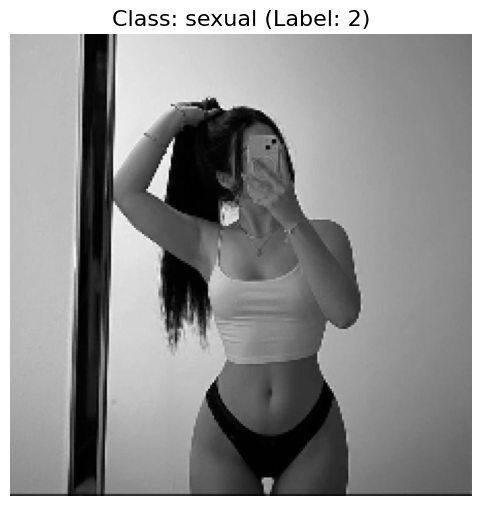

In [45]:
def display_random_image(class_names, images, labels):
    """
    Displays a random image from the dataset along with its class label.

    Args:
        class_names (list): List of class names.
        images (np.ndarray): Array of images.
        labels (np.ndarray): Array of corresponding labels.
    """
    random_index = np.random.randint(0, len(images))

    random_image = images[random_index]
    random_label = labels[random_index]

    class_name = class_names[random_label]

    plt.figure(figsize=(6, 6))
    plt.imshow(random_image.squeeze(), cmap='gray')
    plt.title(f"Class: {class_name} (Label: {random_label})", fontsize=16)
    plt.axis('off')
    plt.show()


display_random_image(CLASS_NAMES, train_images, train_labels)

# Display some dataset

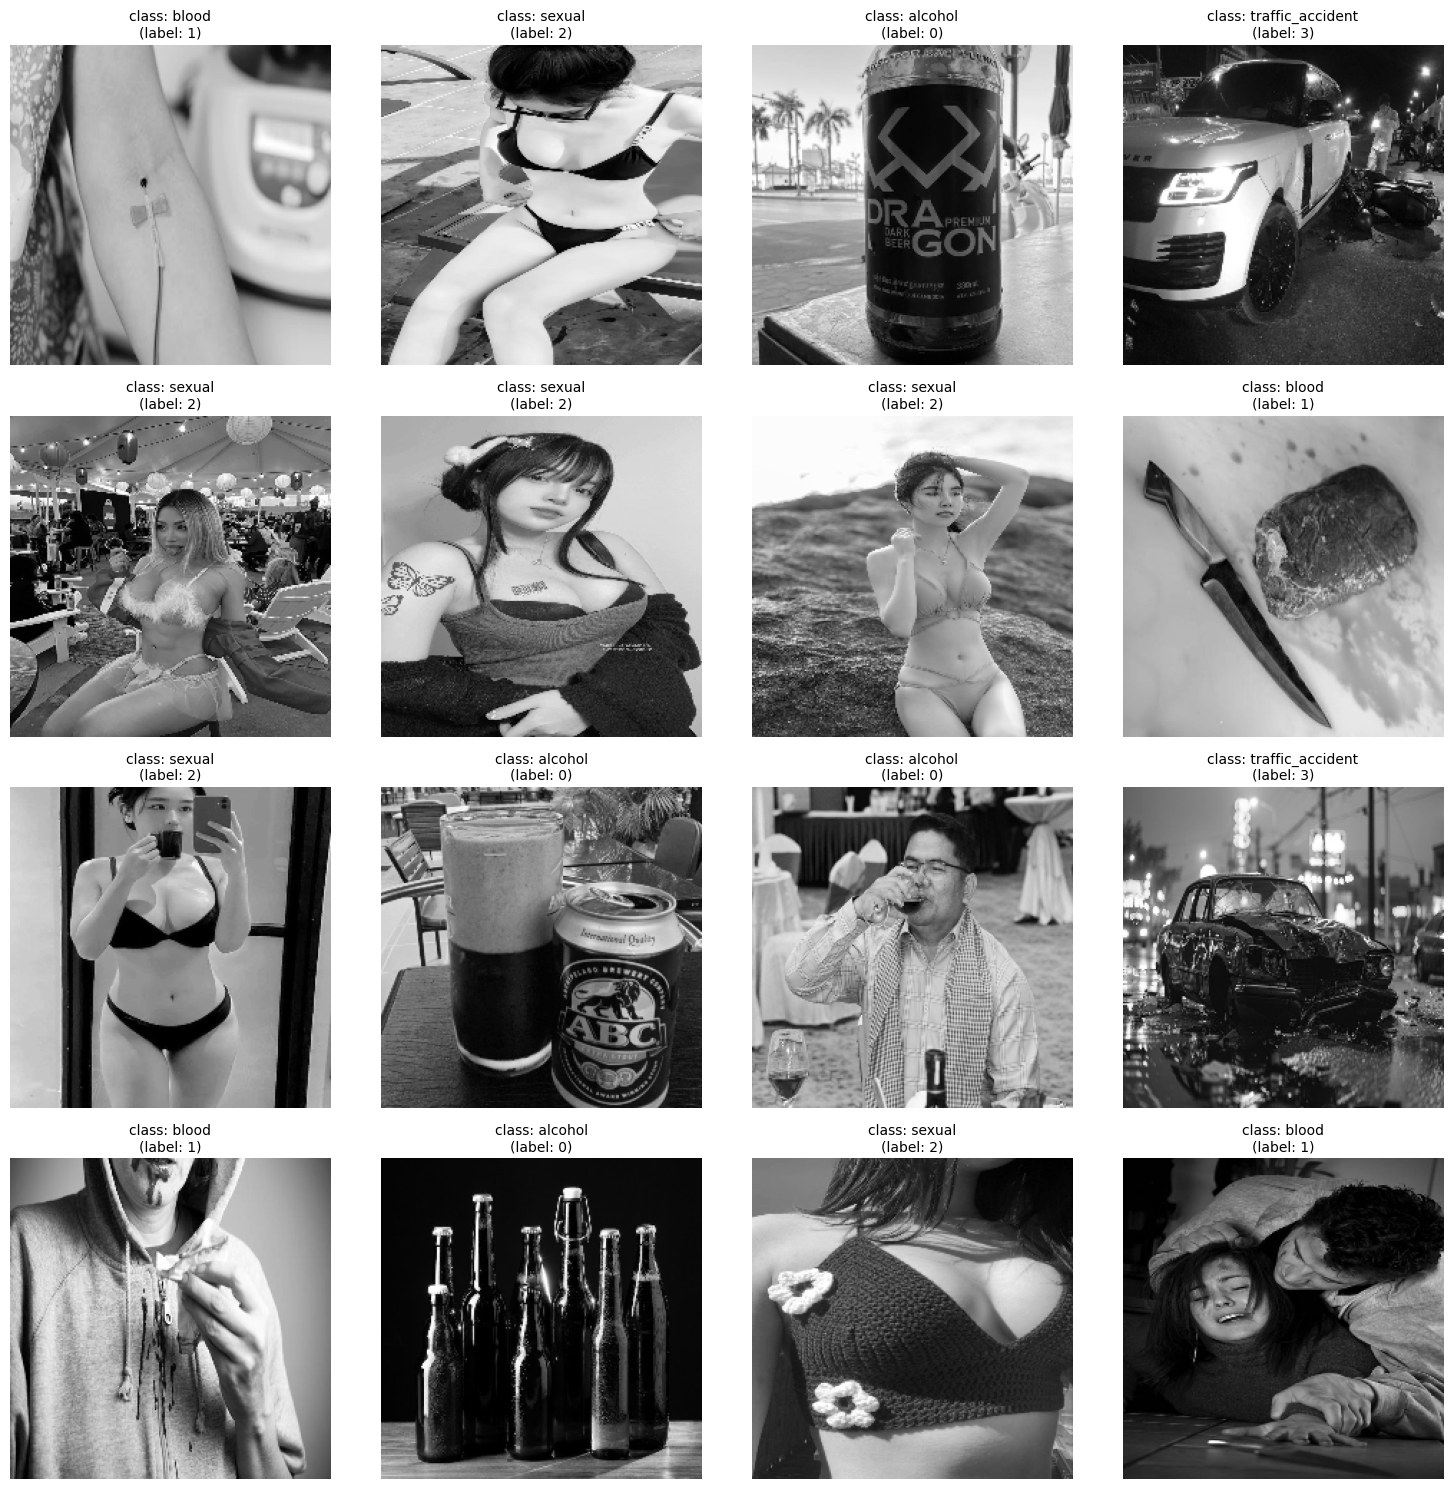

In [46]:
def display_dataset(class_names, images, labels, num_images=16):
    """
    Displays a grid of images from the dataset along with their class labels.

    Args:
        class_names (list): List of class names.
        images (np.ndarray): Array of images.
        labels (np.ndarray): Array of corresponding labels.
        num_images (int): Number of images to display (default: 16).
    """
    num_images = min(num_images, len(images))

    random_indices = np.random.choice(len(images), num_images, replace=False)

    cols = int(np.sqrt(num_images))
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(15, 15 * rows / cols))

    for i, idx in enumerate(random_indices):
        image = images[idx]
        label = labels[idx]
        class_name = class_names[label]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f"class: {class_name}\n(label: {label})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


display_dataset(CLASS_NAMES, train_images, train_labels)

# Model architecture

In [47]:
model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=INPUT_SHAPE, kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding='same', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), padding='same', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dropout(0.5),

    Dense(64, activation='relu', kernel_regularizer=L2(0.001)),
    Dropout(0.5),

    Dense(NB_CLASSES, activation='softmax')
])

# model summary

In [48]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,348 (13.74 MB)

 Trainable params: 3,600,388 (13.73 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile the model

In [49]:
# Optimizer
optimizer = AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-5)

# Compile
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

run = mlflow.start_run()

# Callbacks
callbacks = [
    CSVLogger(os.path.join(LOG_DIR, 'training_log_v16.csv'), append=False),
    TensorBoard(log_dir=os.path.join(LOG_DIR, "tensorboard_logs"), histogram_freq=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, save_weights_only=False,
                    verbose=1),
    mlflow.keras.MlflowCallback(run)
]

# Train
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

mlflow.end_run()

# Save Model
model.save(MODEL_SAVE_PATH)
np.save(HISTORY_PATH, history.history)

Epoch 1/200

Epoch 1: val_loss improved from inf to 1.75942, saving model to output/model/v16/cnn_model_v16.keras
94/94 - 110s - 1s/step - accuracy: 0.2541 - loss: 2.2055 - val_accuracy: 0.2686 - val_loss: 1.7594 - learning_rate: 5.0000e-04
Epoch 2/200

Epoch 2: val_loss improved from 1.75942 to 1.73203, saving model to output/model/v16/cnn_model_v16.keras
94/94 - 109s - 1s/step - accuracy: 0.2687 - loss: 1.7477 - val_accuracy: 0.2686 - val_loss: 1.7320 - learning_rate: 5.0000e-04
Epoch 3/200

Epoch 3: val_loss improved from 1.73203 to 1.70574, saving model to output/model/v16/cnn_model_v16.keras
94/94 - 109s - 1s/step - accuracy: 0.2684 - loss: 1.7203 - val_accuracy: 0.2686 - val_loss: 1.7057 - learning_rate: 5.0000e-04
Epoch 4/200

Epoch 4: val_loss improved from 1.70574 to 1.68117, saving model to output/model/v16/cnn_model_v16.keras
94/94 - 110s - 1s/step - accuracy: 0.2684 - loss: 1.6960 - val_accuracy: 0.2686 - val_loss: 1.6812 - learning_rate: 5.0000e-04
Epoch 5/200

Epoch 5: va

# Evaluate the model

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.2447 - loss: 1.3819
Test Loss: 1.3883, Test Accuracy: 0.2447
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step
Classification Report:
                   precision    recall  f1-score   support

         alcohol       0.00      0.00      0.00       100
           blood       0.24      1.00      0.39        92
          sexual       0.00      0.00      0.00       105
traffic_accident       0.00      0.00      0.00        79

        accuracy                           0.24       376
       macro avg       0.06      0.25      0.10       376
    weighted avg       0.06      0.24      0.10       376



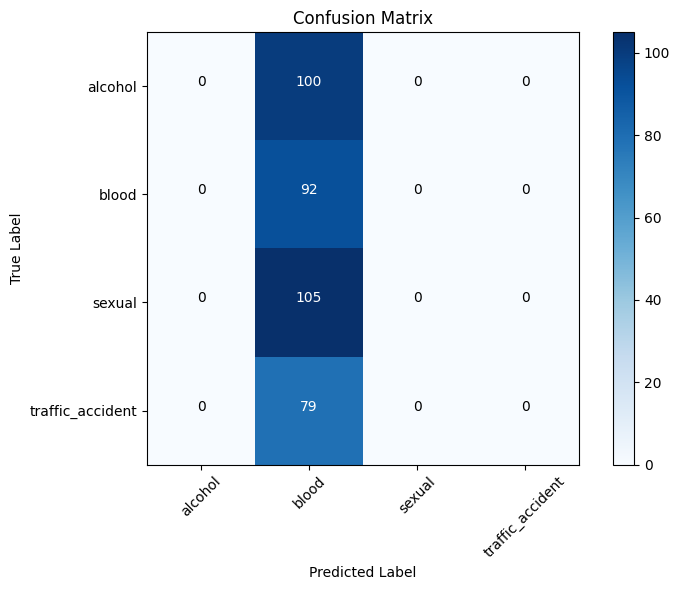

In [50]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Generate predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
report = classification_report(test_labels, y_pred_classes, target_names=CLASS_NAMES)
print("Classification Report:\n", report)

cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{PLOT_SAVE_DIR}confusion_matrix.png")
plt.show()

In [51]:
from keras.src.saving import load_model

best_model = load_model(MODEL_SAVE_PATH)

test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"✅ Best Model Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.2447 - loss: 1.3819
✅ Best Model Accuracy: 0.2447, Loss: 1.3883
